In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

In [2]:
# Get where the notebook is currently running
current_path = os.getcwd() 

# If you are inside the 'notebook' folder, you need to go up one level
# to get to the ISL folder.
parent_path = os.path.abspath(os.path.join(current_path, ".."))

# Now build the full path
csv_path = os.path.join(parent_path, "dataset", "raw", "isl_landmarks.csv")

print(f"Looking for file at: {csv_path}")
df = pd.read_csv(csv_path)

Looking for file at: e:\MANUMOTION\ISL\dataset\raw\isl_landmarks.csv


In [3]:
print("Dataset shape:", df.shape)

print("\nLabel distribution:")

print(df["label"].value_counts())

Dataset shape: (26150, 127)

Label distribution:
label
Z    1268
B    1251
M    1247
D    1203
Y    1176
V    1164
L    1091
T    1072
N    1063
E    1014
A    1013
U    1013
S     999
X     969
F     962
C     934
R     902
G     892
Q     887
P     886
H     879
I     878
O     871
W     843
J     839
K     834
Name: count, dtype: int64


In [4]:
X = df.drop("label", axis=1)

y = df["label"]

In [5]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [6]:
joblib.dump(

encoder,

"../models/label_encoder.pkl"

)

print("Label encoder saved")

Label encoder saved


In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=0.2,

    stratify=y_encoded,

    random_state=42

)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

joblib.dump(

scaler,

"../models/scaler.pkl"

)

print("Scaler saved")

Scaler saved


In [9]:
knn = KNeighborsClassifier(

    n_neighbors=5,

    weights="distance",

    metric="euclidean"

)

In [10]:
knn.fit(

    X_train,

    y_train

)

print("KNN training completed")

KNN training completed


In [11]:
y_pred = knn.predict(

    X_test

)

e:\MANUMOTION\islenv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "e:\MANUMOTION\islenv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\aatif\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\aatif\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\aatif\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1440, in _execute_child
    hp, ht, pid, tid = _win

In [12]:
accuracy = accuracy_score(

    y_test,

    y_pred

)

print("KNN Accuracy:", accuracy)

KNN Accuracy: 0.9988527724665393


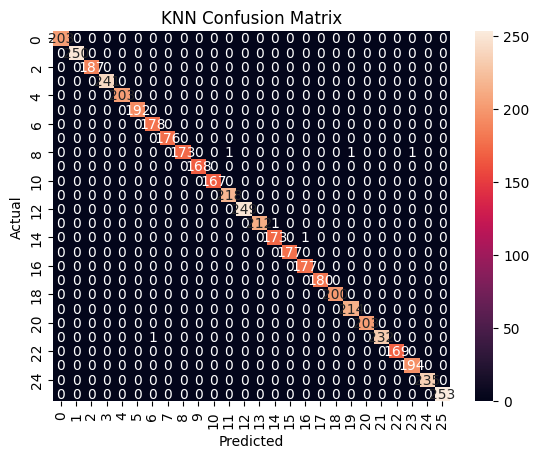

In [13]:
cm = confusion_matrix(

    y_test,

    y_pred

)

plt.figure()

sns.heatmap(

    cm,

    annot=True,

    fmt="d"

)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [14]:
print(

classification_report(

    y_test,

    y_pred

)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       203
           1       1.00      1.00      1.00       250
           2       1.00      1.00      1.00       187
           3       1.00      1.00      1.00       241
           4       1.00      1.00      1.00       203
           5       1.00      1.00      1.00       192
           6       0.99      1.00      1.00       178
           7       1.00      1.00      1.00       176
           8       1.00      0.98      0.99       176
           9       1.00      1.00      1.00       168
          10       1.00      1.00      1.00       167
          11       1.00      1.00      1.00       218
          12       1.00      1.00      1.00       249
          13       1.00      1.00      1.00       213
          14       0.99      0.99      0.99       174
          15       1.00      1.00      1.00       177
          16       0.99      1.00      1.00       177
          17       1.00    

In [15]:
joblib.dump(

knn,

"../models/knn_model.pkl"

)

print("KNN model saved")

KNN model saved
